## Introduction

This notebook is a very basic   example of LightGBM model and a showcase of a package octopus-ml:
[https://github.com/gershonc/octopus-ml](https://github.com/gershonc/octopus-ml)


In [1]:
# Octopus ML pakage - github.com/gershonc/octopus-ml
!pip install octopus-ml --upgrade

You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [2]:
import warnings
warnings.simplefilter("ignore")
import seaborn as sns 
import matplotlib.pyplot as plt
import time
import pandas as pd
import numpy as np
import lightgbm as lgb
import tracemalloc
from pandas_summary import DataFrameSummary
from sklearn.metrics import classification_report
%matplotlib inline
sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)  # or 1000
pd.set_option('display.max_rows', None)  # or 1000
pd.set_option('display.max_colwidth', -1)  # or 199

#check out https://github.com/gershonc/octopus-ml
import octopus_ml as oc

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


## Load the datasets  

In [3]:
train_df = pd.read_csv ( "../input/titanic/train.csv")
test_df = pd.read_csv("../input/titanic/test.csv")

## EDA

In [4]:
# Data shape 
print ("Train set: ",train_df.shape)
print ("Test set: ",test_df.shape)

Train set:  (891, 12)
Test set:  (418, 11)


In [5]:
# DataFrane Summary by pandas summary package (extension of pandas.describe method) 
dfs = DataFrameSummary(train_df)
dfs.summary()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,NaN,NaN,714.000000,891.000000,891.000000,NaN,891.000000,NaN,NaN
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN
max,891.000000,1.000000,3.000000,NaN,NaN,80.000000,8.000000,6.000000,NaN,512.329200,NaN,NaN
counts,891,891,891,891,891,714,891,891,891,891,204,889
uniques,891,2,3,891,2,88,7,7,681,248,147,3


### Mimissing data analysis 

<AxesSubplot:>

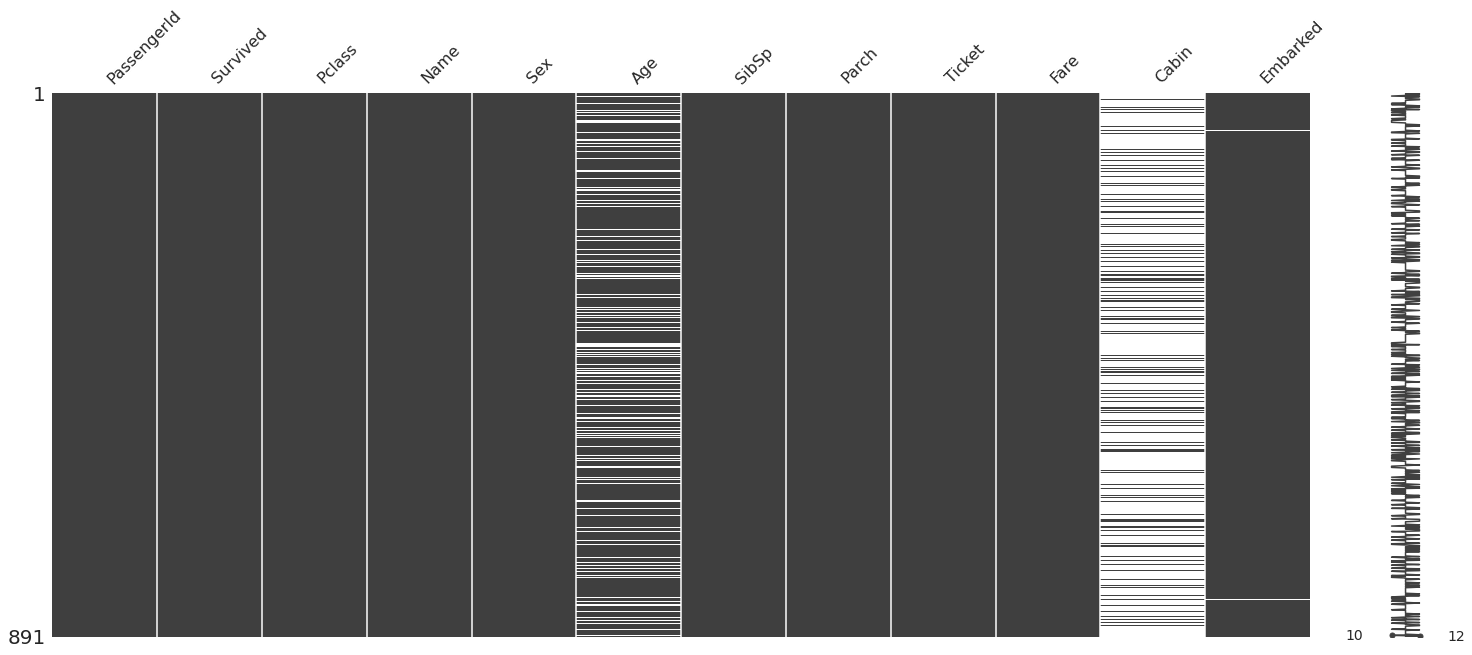

In [6]:
import missingno as msno
msno.matrix(train_df)
# The dataset is quite full, there are sparse areas which are mainly the lab results (low frequency data)

In [7]:
# Top 5 sparse features, mainly labs results 
pd.Series(1 - train_df.count() / len(train_df)).sort_values(ascending=False).head(5)

Cabin          0.771044
Age            0.198653
Embarked       0.002245
PassengerId    0.000000
Survived       0.000000
dtype: float64

<Figure size 216x288 with 0 Axes>

<AxesSubplot:xlabel='Survived', ylabel='count'>

<AxesSubplot:ylabel='Survived'>

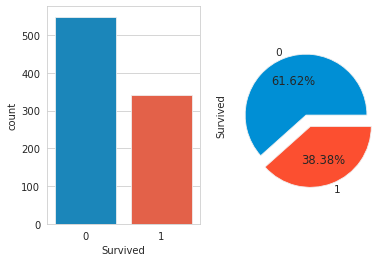

<Figure size 216x288 with 0 Axes>

In [8]:
# Target distribution analysis
fig, ax =plt.subplots(1,2)


plt.style.use('fivethirtyeight')
plt.figure(figsize=(3,4))
sns.set_context("paper", font_scale=1.2)                                                  
sns.countplot('Survived',data=train_df, ax=ax[0])
train_df['Survived'].value_counts().plot.pie(explode=[0,0.2],autopct='%1.2f%%',ax=ax[1])
fig.show()

# it's a slightly imbalanced datast  

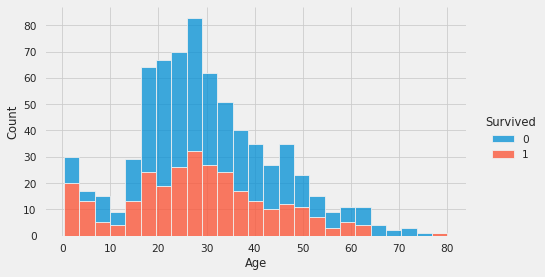

In [9]:
sns.displot(data = train_df, kind = 'hist', x = 'Age', hue = 'Survived', multiple = 'stack',bins=25,height = 4, aspect = 1.7)
# The lower the age the survival rate is higher

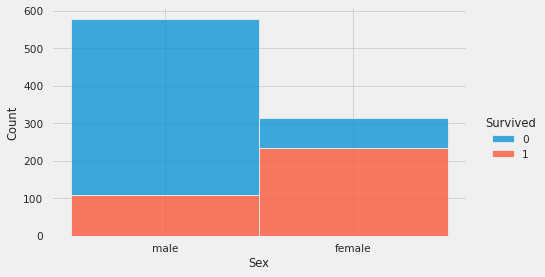

In [10]:
sns.displot(data = train_df, kind = 'hist', x = 'Sex', hue = 'Survived', multiple = 'stack',bins=25,height = 4, aspect = 1.7)
# Female survived in much higher rate than males

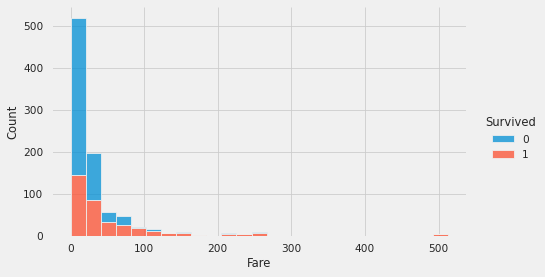

In [11]:
sns.displot(data = train_df, kind = 'hist', x = 'Fare', hue = 'Survived', multiple = 'stack',bins=25,height = 4, aspect = 1.7)
# the higher the fare the survival rate is high as well

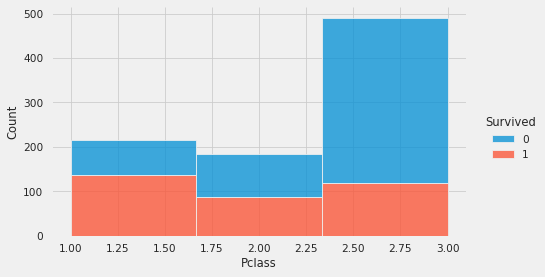

In [12]:
sns.displot(data = train_df, kind = 'hist', x = 'Pclass', hue = 'Survived', multiple = 'stack',bins=3,height = 4, aspect = 1.7)

# Pclass 3 has the lowest survival rate  

<Figure size 216x288 with 0 Axes>

<Figure size 216x288 with 0 Axes>

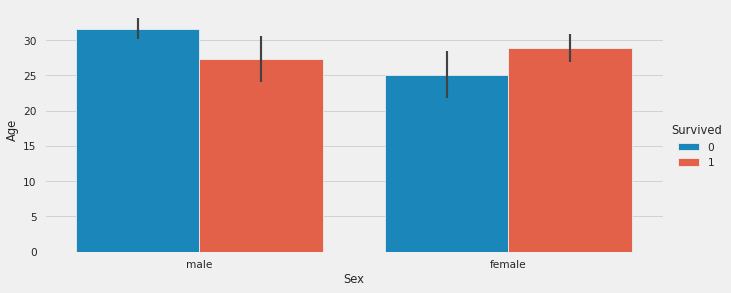

In [13]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(3,4))
sns.set_context("paper", font_scale=1.2)   
sns.factorplot(x="Sex", y="Age", hue="Survived", data=train_df, kind="bar",height = 4, aspect = 2.3)

# the survival rate is higher in older females and younger males

## Data pre-processing 

In [14]:
train_df['Embarked'].fillna('S',inplace = True)
test_df['Embarked'].fillna('S',inplace = True)

In [15]:
#remove null value from Age

print('Median Age of the train passengers: ',train_df['Age'].median())
print(train_df['Age'].isnull().sum(),test_df['Age'].isnull().sum(),"null values present in train, test")
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)

print('Median Age of the test passengers: ',test_df['Age'].median())
test_df['Age'].fillna(test_df['Age'].median(), inplace=True)


Median Age of the train passengers:  28.0
177 86 null values present in train, test
Median Age of the test passengers:  27.0


In [16]:
combined_title = [i.split(",")[1].split(".")[0].strip() for i in train_df["Name"]]
train_df["Title"] = pd.Series(combined_title)
train_df["Title"] = train_df["Title"].replace(['Lady', 'the Countess','Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df["Title"] = train_df["Title"].map({"Master":0, "Miss":1, "Ms" : 1 , "Mme":1, "Mlle":1, "Mrs":1, "Mr":2, "Rare":3})
train_df["Title"] = train_df["Title"].astype('category')

combined_title = [i.split(",")[1].split(".")[0].strip() for i in test_df["Name"]]
test_df["Title"] = pd.Series(combined_title)
test_df["Title"] = test_df["Title"].replace(['Lady', 'the Countess','Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
test_df["Title"] = test_df["Title"].map({"Master":0, "Miss":1, "Ms" : 1 , "Mme":1, "Mlle":1, "Mrs":1, "Mr":2, "Rare":3})
test_df["Title"] = test_df["Title"].astype('category')


In [17]:
Ticket = []
for i in list(train_df.Ticket):
    if not i.isdigit() :
        Ticket.append(i.replace(".","").replace("/","").strip().split(' ')[0]) #Take prefix
    else:
        Ticket.append("X")
        
train_df["Ticket"] = Ticket
train_df["Ticket"].head()

Ticket2 = []
for i in list(test_df.Ticket):
    if not i.isdigit() :
        Ticket2.append(i.replace(".","").replace("/","").strip().split(' ')[0]) #Take prefix
    else:
        Ticket2.append("X")
        
test_df["Ticket"] = Ticket2
test_df["Ticket"].head()


0    A5    
1    PC    
2    STONO2
3    X     
4    X     
Name: Ticket, dtype: object

0    X
1    X
2    X
3    X
4    X
Name: Ticket, dtype: object

In [18]:
train_df['Ticket_Frequency'] = train_df.groupby('Ticket')['Ticket'].transform('count')
test_df['Ticket_Frequency'] = test_df.groupby('Ticket')['Ticket'].transform('count')

In [19]:
import re

deck = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "U": 8}
data = [train_df, test_df]

for dataset in data:
    # Modification of cabin column to keep only the letter contained corresponding to the deck of the boat

    dataset['Cabin'] = dataset['Cabin'].fillna("U0")
    dataset['Deck'] = dataset['Cabin'].map(lambda x: re.compile("([a-zA-Z]+)").search(x).group())
    dataset['Deck'] = dataset['Deck'].map(deck)
    dataset['Deck'] = dataset['Deck'].fillna(0)
    dataset['Deck'] = dataset['Deck'].astype('category')
    
    #calculate feature that shows number of relatives on the ship 

    dataset['relatives'] = dataset['SibSp'] + dataset['Parch']
    dataset.loc[dataset['relatives'] > 0, 'not_alone'] = 0
    dataset.loc[dataset['relatives'] == 0, 'not_alone'] = 1
    dataset['not_alone'] = dataset['not_alone'].astype(int)

    # Create a Title column from name column
    # dataset['Title'] = pd.Series((name.split('.')[0].split(',')[1].strip() for name in dataset['Name']), index=dataset.index)
    # dataset['Title'] = dataset['Title'].replace(['Lady', 'the Countess','Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    # dataset['Title'] = dataset['Title'].replace(['Mlle', 'Ms'], 'Miss')
    # dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')
    # dataset['Title'] = dataset['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5})

In [20]:
def encodeAgeFare(train):
    train.loc[train['Age'] <= 16, 'Age_fare'] = 0
    train.loc[(train['Age'] > 16) & (train['Age'] <= 32), 'Age_fare'] = 1
    train.loc[(train['Age'] > 32) & (train['Age'] <= 48), 'Age_fare'] = 2
    train.loc[(train['Age'] > 48) & (train['Age'] <= 64), 'Age_fare'] = 3
    train.loc[ (train['Age'] > 48) & (train['Age'] <= 80), 'Age_fare'] = 4
    
    train.loc[train['Fare'] <= 7.91, 'Fare'] = 0
    train.loc[(train['Fare'] > 7.91) & (train['Fare'] <= 14.454), 'Fare_adj'] = 1
    train.loc[(train['Fare'] > 14.454) & (train['Fare'] <= 31.0), 'Fare_adj'] = 2
    train.loc[(train['Fare'] > 31.0) & (train['Fare'] <= 512.329), 'Fare_adj'] = 3

encodeAgeFare(train_df)
encodeAgeFare(test_df)

In [21]:
train_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Ticket_Frequency,Deck,relatives,not_alone,Age_fare,Fare_adj
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A5,0.0000,U0,S,2,21,8.0,1,0,1.0,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC,71.2833,C85,C,1,60,3.0,1,0,2.0,3.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STONO2,7.9250,U0,S,1,6,8.0,0,1,1.0,1.0


In [22]:
features=train_df.columns.to_list()
print ('Number of features ', len(features)-1)
features_remove=['Survived']
for f in features_remove:
    features.remove(f)

Number of features  18


In [23]:
# Categorical features

categorical_features=[]
for c in train_df.columns:
    col_type = train_df[c].dtype
    if col_type == 'object' or col_type.name == 'category':
        train_df[c] = train_df[c].astype('category')
        categorical_features.append(c)
print (categorical_features)

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Title', 'Deck']


In [24]:
X=train_df[features]
y=train_df['Survived']

## OCTOPUS-ML functions
[https://github.com/gershonc/octopus-ml](https://github.com/gershonc/octopus-ml)

## Model Training (LightGBM)

In [25]:
params = {
        'boosting_type': 'gbdt',
        'objective': 'binary',
        'metric': 'auc',
        'learning_rate': 0.05,
        'n_estimators': 100,
        'verbose': -1,
        'max_depth': -1,
        'seed':100,      
        'min_split_gain': 0.01, 
        'num_leaves': 18, 
        'reg_alpha': 0.071, 
        'reg_lambda': 1.50,
        'feature_fraction':0.2,
        'bagging_fraction':0.84,
        'lambda_l2':2.4777,
        'min_child_weight':20.70, 
        'min_split_gain':0.01363
}

metrics = oc.cv_adv(X,y,0.5,100,shuffle=True,params=params)

0it [00:00, ?it/s]

--------------------------- Running Cross-Validation - classification, mode: full ---------------------------
-> Starting 5-folds CV - Shuffle: True
[LightGBM] [Warning] lambda_l2 is set=2.4777, reg_lambda=1.5 will be ignored. Current value: lambda_l2=2.4777
[1]	training's auc: 0.826116	valid_1's auc: 0.871278
[2]	training's auc: 0.797388	valid_1's auc: 0.795916
[3]	training's auc: 0.797388	valid_1's auc: 0.795916
[4]	training's auc: 0.807676	valid_1's auc: 0.795125
[5]	training's auc: 0.836825	valid_1's auc: 0.840843
[6]	training's auc: 0.845787	valid_1's auc: 0.872332
[7]	training's auc: 0.844418	valid_1's auc: 0.869829
[8]	training's auc: 0.84602	valid_1's auc: 0.861067
[9]	training's auc: 0.848757	valid_1's auc: 0.87635
[10]	training's auc: 0.850931	valid_1's auc: 0.868972
[11]	training's auc: 0.851235	valid_1's auc: 0.87108
[12]	training's auc: 0.850276	valid_1's auc: 0.864229
[13]	training's auc: 0.849642	valid_1's auc: 0.859816
[14]	training's auc: 0.847781	valid_1's auc: 0.8527

1it [00:00,  3.95it/s]

[99]	training's auc: 0.872216	valid_1's auc: 0.882279
[100]	training's auc: 0.872083	valid_1's auc: 0.882148
[LightGBM] [Warning] lambda_l2 is set=2.4777, reg_lambda=1.5 will be ignored. Current value: lambda_l2=2.4777
[1]	training's auc: 0.837163	valid_1's auc: 0.826203
[2]	training's auc: 0.841332	valid_1's auc: 0.819786
[3]	training's auc: 0.802533	valid_1's auc: 0.80107
[4]	training's auc: 0.81179	valid_1's auc: 0.801337
[5]	training's auc: 0.845219	valid_1's auc: 0.829211
[6]	training's auc: 0.857473	valid_1's auc: 0.835762
[7]	training's auc: 0.857702	valid_1's auc: 0.837299
[8]	training's auc: 0.855312	valid_1's auc: 0.833623
[9]	training's auc: 0.857673	valid_1's auc: 0.835495
[10]	training's auc: 0.858462	valid_1's auc: 0.838035
[11]	training's auc: 0.859398	valid_1's auc: 0.83643
[12]	training's auc: 0.858641	valid_1's auc: 0.840909
[13]	training's auc: 0.855681	valid_1's auc: 0.844452
[14]	training's auc: 0.850594	valid_1's auc: 0.841511
[15]	training's auc: 0.857369	valid_1

2it [00:00,  4.28it/s]

...

[73]	training's auc: 0.873485	valid_1's auc: 0.839037
[74]	training's auc: 0.873921	valid_1's auc: 0.840107
[75]	training's auc: 0.874038	valid_1's auc: 0.839706
[76]	training's auc: 0.874204	valid_1's auc: 0.840241
[77]	training's auc: 0.874528	valid_1's auc: 0.840508
[78]	training's auc: 0.874936	valid_1's auc: 0.84238
[79]	training's auc: 0.875002	valid_1's auc: 0.84238
[80]	training's auc: 0.875118	valid_1's auc: 0.842513
[81]	training's auc: 0.875235	valid_1's auc: 0.843048
[82]	training's auc: 0.875335	valid_1's auc: 0.843048
[83]	training's auc: 0.875401	valid_1's auc: 0.842781
[84]	training's auc: 0.875825	valid_1's auc: 0.843583
[85]	training's auc: 0.876465	valid_1's auc: 0.84492
[86]	training's auc: 0.876573	valid_1's auc: 0.845588
[87]	training's auc: 0.876952	valid_1's auc: 0.846791
[88]	training's auc: 0.877517	valid_1's auc: 0.847727
[89]	training's auc: 0.877384	valid_1's auc: 0.847326
[90]	training's auc: 0.877367	valid_1's auc: 0.84746
[91]	training's auc: 0.877226	va

4it [00:00,  4.38it/s]

[37]	training's auc: 0.865612	valid_1's auc: 0.834826
[38]	training's auc: 0.865845	valid_1's auc: 0.835227
[39]	training's auc: 0.865462	valid_1's auc: 0.83516
[40]	training's auc: 0.866194	valid_1's auc: 0.835829
[41]	training's auc: 0.866967	valid_1's auc: 0.836364
[42]	training's auc: 0.866851	valid_1's auc: 0.836497
[43]	training's auc: 0.867304	valid_1's auc: 0.836096
[44]	training's auc: 0.867661	valid_1's auc: 0.835294
[45]	training's auc: 0.86806	valid_1's auc: 0.834492
[46]	training's auc: 0.868734	valid_1's auc: 0.834091
[47]	training's auc: 0.868742	valid_1's auc: 0.834358
[48]	training's auc: 0.869652	valid_1's auc: 0.833088
[49]	training's auc: 0.870026	valid_1's auc: 0.833623
[50]	training's auc: 0.870687	valid_1's auc: 0.83369
[51]	training's auc: 0.87097	valid_1's auc: 0.83369
[52]	training's auc: 0.870521	valid_1's auc: 0.834425
[53]	training's auc: 0.870546	valid_1's auc: 0.834425
[54]	training's auc: 0.87107	valid_1's auc: 0.835361
[55]	training's auc: 0.870995	vali

5it [00:01,  4.47it/s]



[25]	training's auc: 0.844743	valid_1's auc: 0.894362
[26]	training's auc: 0.846966	valid_1's auc: 0.893432
[27]	training's auc: 0.847998	valid_1's auc: 0.893565
[28]	training's auc: 0.848073	valid_1's auc: 0.8929
[29]	training's auc: 0.848239	valid_1's auc: 0.893831
[30]	training's auc: 0.848726	valid_1's auc: 0.8929
[31]	training's auc: 0.84846	valid_1's auc: 0.892634
[32]	training's auc: 0.851074	valid_1's auc: 0.889642
[33]	training's auc: 0.851157	valid_1's auc: 0.890174
[34]	training's auc: 0.852306	valid_1's auc: 0.89177
[35]	training's auc: 0.852772	valid_1's auc: 0.892435
[36]	training's auc: 0.853788	valid_1's auc: 0.893365
[37]	training's auc: 0.854679	valid_1's auc: 0.893498
[38]	training's auc: 0.854337	valid_1's auc: 0.892833
[39]	training's auc: 0.855961	valid_1's auc: 0.893099
[40]	training's auc: 0.857222	valid_1's auc: 0.891304
[41]	training's auc: 0.857746	valid_1's auc: 0.890507
[42]	training's auc: 0.858379	valid_1's auc: 0.890507
[43]	training's auc: 0.858421	val

## Model evaluation


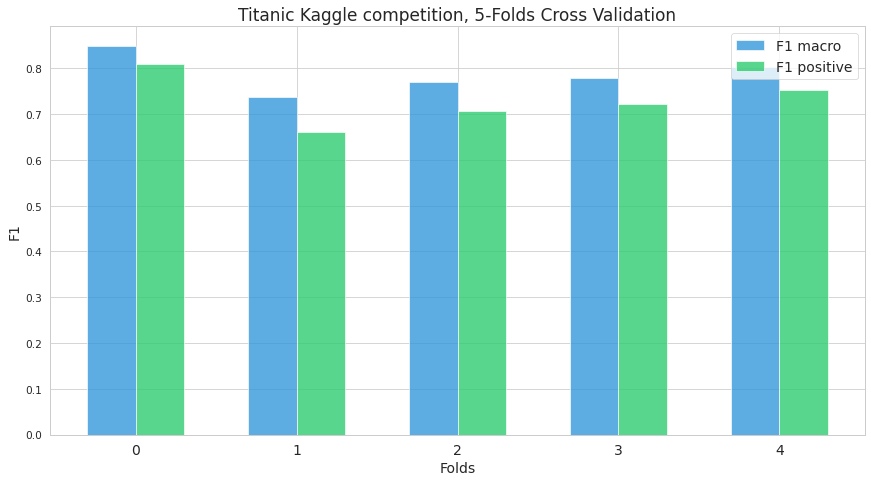

In [26]:
oc.cv_plot(metrics['f1_weighted'],metrics['f1_macro'],metrics['f1_positive'],'Titanic Kaggle competition')

In [27]:
print(classification_report(metrics['y'], metrics['predictions_folds']))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       549
           1       0.77      0.70      0.73       342

    accuracy                           0.80       891
   macro avg       0.79      0.78      0.79       891
weighted avg       0.80      0.80      0.80       891



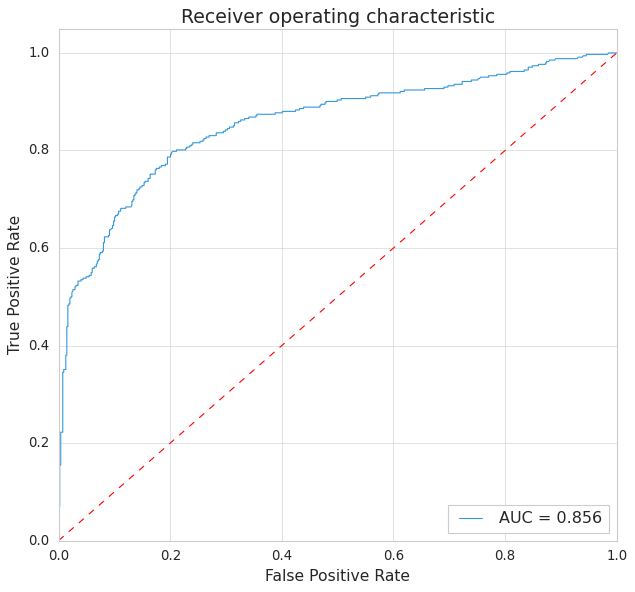

In [28]:
oc.roc_curve_plot(metrics['y'], metrics['predictions_proba'])

<Figure size 640x480 with 0 Axes>

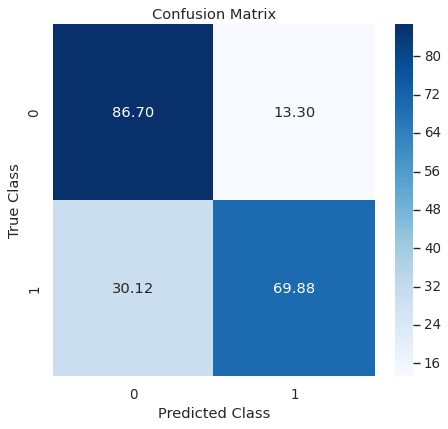

<Figure size 640x480 with 0 Axes>

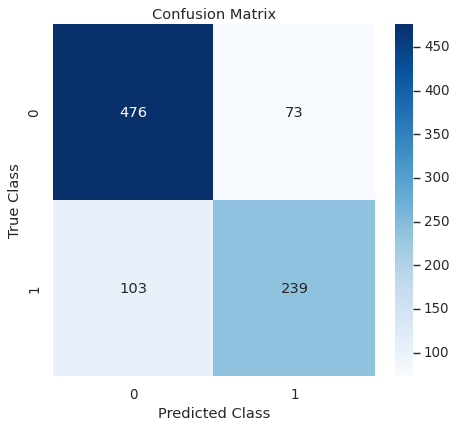

In [29]:
oc.confusion_matrix_plot(metrics['y'], metrics['predictions_folds'])

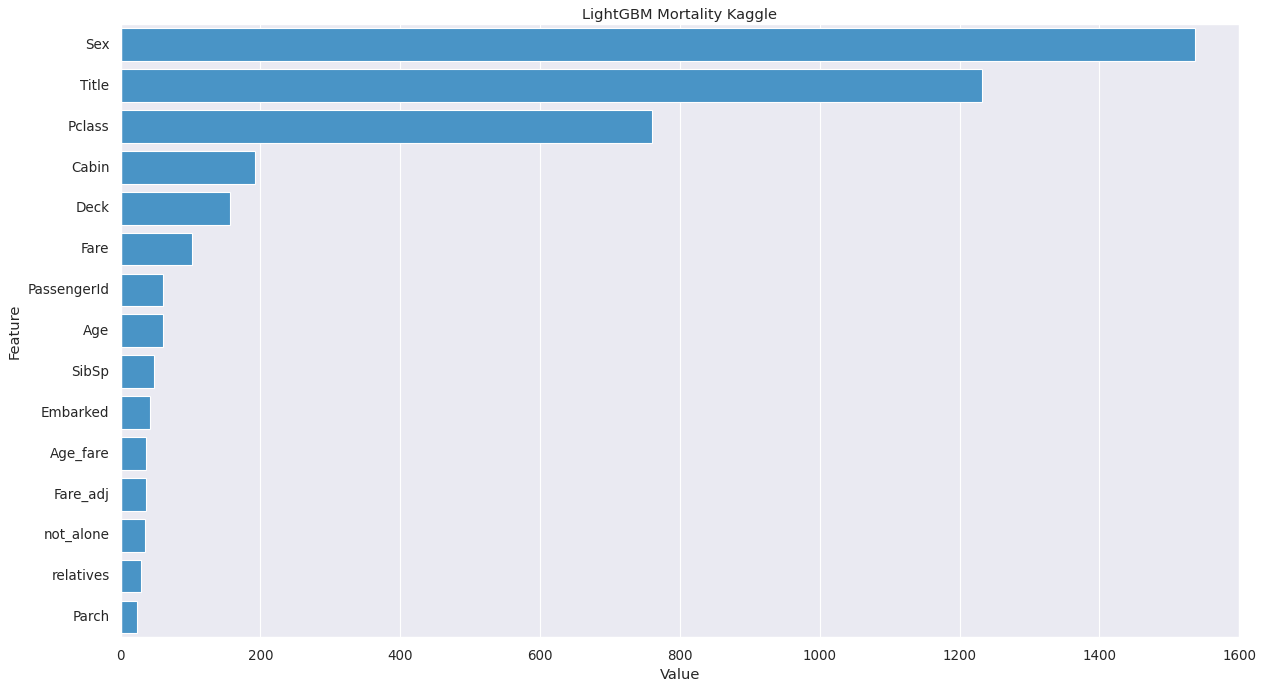

In [30]:
feature_imp_list=oc.plot_imp(metrics['final_clf'],X,'LightGBM Mortality Kaggle',num=15)

In [31]:
top_features=feature_imp_list.sort_values(by='Value', ascending=False).head(20)
top_features


,Value,Feature
3,1536.360318,Sex
11,1232.005733,Title
1,759.386764,Pclass
9,191.685994,Cabin
13,156.517185,Deck
8,101.941634,Fare
0,60.690798,PassengerId
4,60.669009,Age
5,47.062495,SibSp
10,41.513709,Embarked


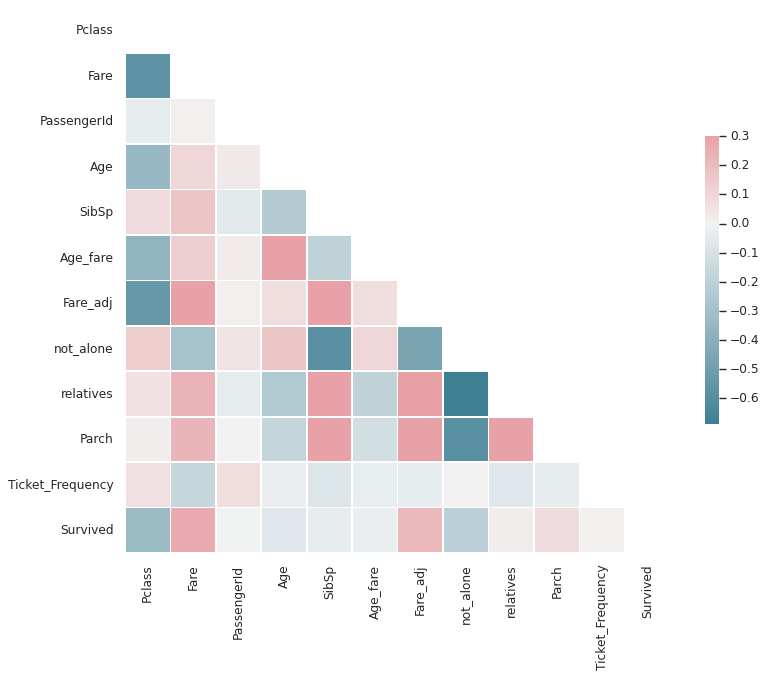

In [32]:
list_for_correlations=top_features['Feature'].to_list()
list_for_correlations.append('Survived')
oc.correlations(train_df,list_for_correlations)

# following the EDA above, we can see the same correlations, SibSp shows opposite correlation (families were less fortunate to survive)

Best score using built-in LassoCV: 0.189678


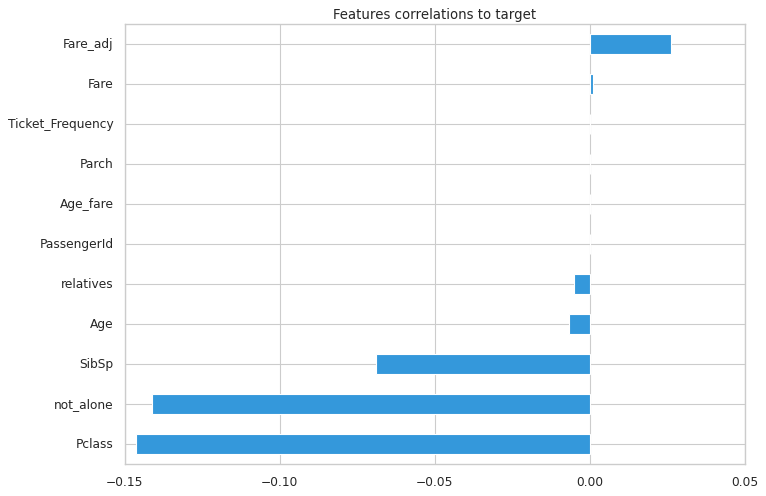

In [33]:
oc.target_corr(X,y,top_features['Feature'].to_list())

In [34]:
oc.data_leakage(X,top_features['Feature'].to_list())

->  Passed the data leakage test - no duplicate intstances detected 
Method Name       : data_leakage
Current memory usage: 0.03356MB
Peak                : 0.262523MB
Total time taken:   10.467 ms 


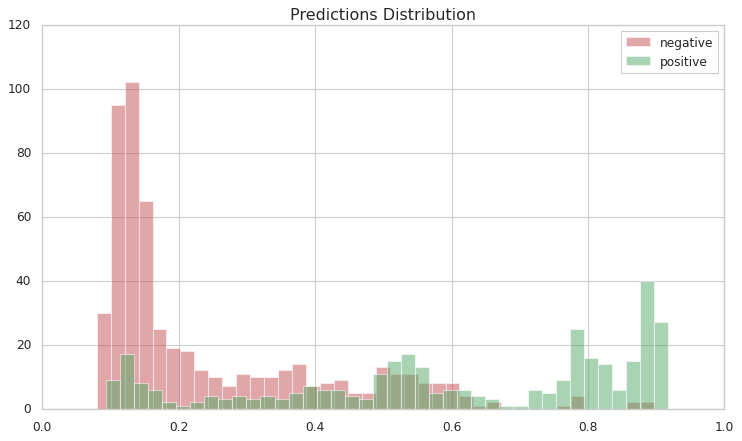

<AxesSubplot:title={'center':'Predictions Distribution'}>

In [35]:
oc.preds_distribution(metrics['y'], metrics['predictions_proba'], bins=40)

In [36]:
fps=oc.recieve_fps(X, metrics['index'] ,metrics['y'], metrics['predictions_proba'],top=10)
fns=oc.recieve_fns(X, metrics['index'] ,metrics['y'], metrics['predictions_proba'],top=10)

calculating using threshold of:  0.5
calculating using threshold of:  0.5


In [37]:
fps

,index,label,preds_proba,preds_class
0,297,0,0.897961,1
1,772,0,0.886947,1
2,498,0,0.867452,1
3,177,0,0.867339,1
4,312,0,0.791207,1
5,357,0,0.789997,1
6,199,0,0.788933,1
7,41,0,0.783000,1
8,854,0,0.758208,1
9,745,0,0.666491,1


In [38]:
fns

,index,label,preds_proba,preds_class
0,107,1,0.093164,0
1,414,1,0.099960,0
2,828,1,0.101824,0
3,36,1,0.103185,0
4,127,1,0.109716,0
5,569,1,0.110798,0
6,267,1,0.111144,0
7,400,1,0.111419,0
8,338,1,0.112984,0
9,81,1,0.114076,0


## Test Submission 

In [39]:
def Kaggle_submission(file_name,model,test_data,ids_list):
    if TARGET in test_data.columns:
        test_data.drop([TARGET],axis=1,inplace=True)
    #test_pred=model.predict(test_data[features])[:,1]
    test_pred=model.predict(test_data[features])
    predictions = []
    predictions = oc.adjusted_classes(test_pred, 0.5)

    submit=pd.DataFrame()
    submit['PassengerId'] = ids_list
    submit['Survived'] = predictions
    submit.to_csv(file_name,index=False)
    return submit

In [40]:
# Categorical features on testset

categorical_features=[]
for c in test_df.columns:
    col_type = train_df[c].dtype
    if col_type == 'object' or col_type.name == 'category':
        test_df[c] = test_df[c].astype('category')
        categorical_features.append(c)
print (categorical_features)

TARGET="Survived"
submit=Kaggle_submission("LGBM_baseline_final_clf.csv",metrics['final_clf'],test_df,test_df['PassengerId'].tolist())

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Title', 'Deck']


In [41]:
test_pred=metrics['final_clf'].predict(test_df[features])
predictions = []
predictions = oc.adjusted_classes(test_pred, 0.5)

In [42]:
test_pred[1:20]

array([0.4266474 , 0.13910133, 0.12348272, 0.43561011, 0.14290457,
       0.56368641, 0.20685739, 0.56418745, 0.12603288, 0.10170266,
       0.18720812, 0.9120652 , 0.15635591, 0.89729919, 0.79516817,
       0.16665359, 0.11179382, 0.46166356, 0.51973963])

In [43]:
predictions[0:10]

[0, 0, 0, 0, 0, 0, 1, 0, 1, 0]

In [44]:
submit.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


## Stacked CV 5-folds models 

In [45]:
results=submit.copy()
for i, s_clf in enumerate(metrics['stacked_models']):
    test_pre = (s_clf.predict(test_df))
    results['clf_'+str(i)]=test_pre

col = results.loc[: , "clf_0":"clf_4"]
results['final_proba'] = col.mean(axis=1)
results.head(2)


,PassengerId,Survived,clf_0,clf_1,clf_2,clf_3,clf_4,final_proba
0,892,0,0.099765,0.113624,0.102447,0.096549,0.108248,0.104127
1,893,0,0.413120,0.431474,0.421819,0.471396,0.432252,0.434012


In [46]:
submit['Survived']= oc.adjusted_classes(results['final_proba'], 0.5)
submit.to_csv('stacked_submission.csv',index = False)
submit.head(4)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0


## Sanity test

In [47]:
test_pred=metrics['final_clf'].predict(X[features])
predictions = []
predictions = oc.adjusted_classes(test_pred, 0.5)
print(classification_report(y, predictions))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       549
           1       0.82      0.71      0.76       342

    accuracy                           0.83       891
   macro avg       0.83      0.81      0.82       891
weighted avg       0.83      0.83      0.83       891

